# Buckled honeycomb lattice: charge-density wave, antiferromagnetism, and spin-orbit coupling
Building on the buckled geometry from the previous notebook, we now add three terms that are all relevant for real buckled 2D materials (silicene, germanene) and, together, realize a Kane-Mele-like model with broken symmetries:
$$ H = H_{kin} + H_{CDW} + H_{AF} + H_{SOC} $$
$H_{CDW}$ is a static sublattice imbalance (mimics a perpendicular electric field / charge-density wave), $H_{AF}$ is a staggered exchange field (antiferromagnetic order), and $H_{SOC}$ is intrinsic spin-orbit coupling — the term that, on its own on a flat honeycomb lattice, would realize the Kane-Mele quantum spin Hall insulator.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Build the buckled geometry and add the three terms on top of the kinetic Hamiltonian

In [2]:
g = geometry.buckled_honeycomb_lattice() # create the buckled geometry
h = g.get_hamiltonian() # create hamiltonian of the system
h.add_sublattice_imbalance(0.1) # add sublattice imbalance (CDW)
h.add_antiferromagnetism(0.6) # add antiferromagnetism
h.add_soc(0.06) # add spin-orbit coupling

### Diagonalize the Bloch Hamiltonian
`operator="sz"` requests the expectation value of the spin-$z$ operator on each eigenstate, so we can color the bands by spin.
$$ H |\Psi_k \rangle = \epsilon_k |\Psi_k\rangle,\qquad \langle S_z \rangle_k = \langle \Psi_k| S_z |\Psi_k\rangle $$

In [3]:
(k,e,sz) = h.get_bands(operator="sz") # get the bandstructure

### Plot the Bloch band structure in the path, colored by spin

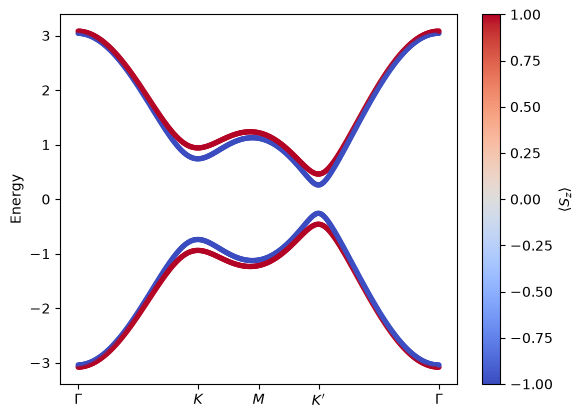

In [4]:
sc = plt.scatter(k/max(k),e,c=sz,cmap="coolwarm",s=8) # do a scatter plot
plt.colorbar(sc,label="$\langle S_z \\rangle$")
plt.ylabel("Energy") # set the y label
plt.xticks([0.,1/3.,0.5,2./3.,1.],["$\Gamma$","$K$","$M$","$K'$","$\Gamma$"])
plt.show() # show the plot